# Sequence to Sequence Learning with Neural Networks

### *Sutskever et al.*

This notebook implements the Machine Translation model used in the paper *Sequence to Sequence Learning
with Neural Networks*.

I create a series of increasingly complex models inspired by the paper. Then, I compare and contrast their ability to translate English to French text using the English to French small dataset from kaggle.

## Evolution


The architecture utilizes LSTMs rather than vanilla RNNs to address the challenge of long-term dependencies. In a standard RNN, the first word of an input sentence (e.g., "Tom") is temporally distant from the final hidden vector passed to the decoder. Consequently, the semantic meaning of early words often gets "washed out" or diluted by the time the encoding is complete. LSTMs mitigate this by preserving gradients over longer sequences.

I show:
> 1) A vanilla RNN implementation of their model, demonstrating that it struggles to represent the meaning of the whole input in the vector.
>2) A LSTM implementation
>3) A Deep LSTM implementation, analogous to their model

Also, I show the improvements from reversing the order of the input sequences before passing to the encoder which was a key success of their paper.

## Data + Setup

#### Imports

In [1]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/english_french.csv')
df.head()

,English,French
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !


In [3]:
df.shape, df.map(len).max()

((229803, 2),
 English    290
 French     349
 dtype: int64)

#### Data Cleaning

Visualising char lengths of examples to remove outliers

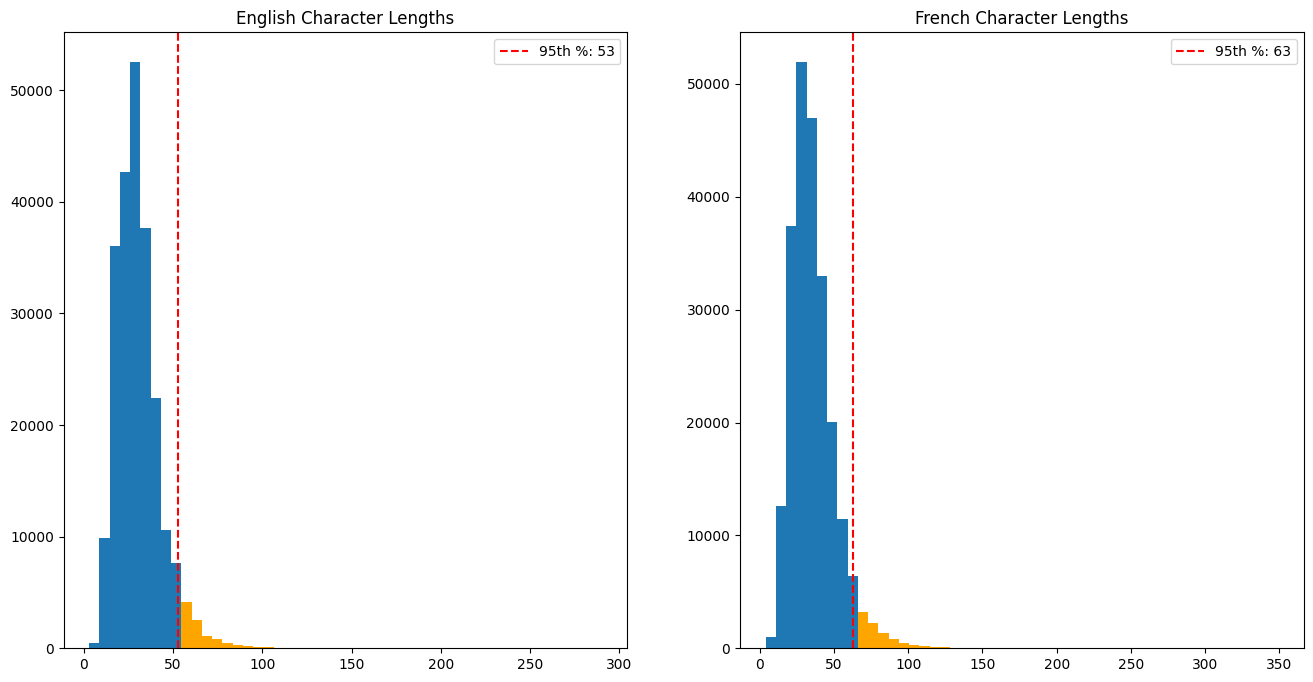

In [4]:
fig,ax = plt.subplots(1,2, figsize = (16,8))

for i, col in enumerate(['English', 'French']):
    lengths = df[col].str.len()
    q95 = lengths.quantile(0.95)
    n,bins, patches = ax[i].hist(lengths, bins = 50, color = 'lightblue')
    for bin_left, patch in zip(bins[:-1], patches):
        if bin_left < q95:
            patch.set_facecolor('#1f77b4')
        else:
            patch.set_facecolor('orange')

    ax[i].axvline(q95, color='red', linestyle='--', label=f'95th %: {q95:.0f}')

    ax[i].set_title(f'{col} Character Lengths')
    ax[i].legend()


**Data Cleaning**

We should filter out the extremely long values to prevent massive padding. I filter out arond the 95th percentile of French texts which also removes outlier texts in the english set.

1) English Characters
* We have soft hyphen and non-breaking space characters, must replace them with "" and " " respectively.
2) French Characters
* We have several other weird characters and odd spaces that I fix

In [5]:
# Weird symbol rows
# df.loc[df['English'].str.contains('[\xa0\xad]',regex=True)]
# df.loc[df['English'].str.contains('₂',regex=True)]

# Clean the text
def clean_data(df):
    clean_df = df.loc[df['French'].str.len() <= 63,: ].copy()

    replacements = {
        '\xa0': ' ',
        '\xad': None,
        '\u2009': ' ',
        '\u200b': '',
        '\u202f': ' ',
    }
    table = str.maketrans(replacements)

    for c in df.columns:
        clean_df[c] = clean_df[c].str.translate(table)

    return clean_df

df = clean_data(df)

**Encode characters**

Special padding tokens, start of sequence and end of sequence tokens to mark key points in translating

In [6]:
english_chars = sorted(set(''.join(df['English'].astype(str))))
french_chars = sorted(list(set(''.join(df['French']))))
special_tokens = ['<PAD>', '<SOS>', '<EOS>']

# Integer to string encodings
fitos = {idx + len(special_tokens):char for idx, char in enumerate(french_chars)}
eitos = {idx + len(special_tokens):char for idx, char in enumerate(english_chars)}

for i, token in enumerate(special_tokens):
    fitos[i] = token
    eitos[i] = token

# String to integer encodings
fstoi ={c:i for i,c in fitos.items()}
estoi ={c:i for i,c in eitos.items()}
estoi

{' ': 3,
 '!': 4,
 '"': 5,
 '$': 6,
 '%': 7,
 '&': 8,
 "'": 9,
 ',': 10,
 '-': 11,
 '.': 12,
 '/': 13,
 '0': 14,
 '1': 15,
 '2': 16,
 '3': 17,
 '4': 18,
 '5': 19,
 '6': 20,
 '7': 21,
 '8': 22,
 '9': 23,
 ':': 24,
 ';': 25,
 '?': 26,
 'A': 27,
 'B': 28,
 'C': 29,
 'D': 30,
 'E': 31,
 'F': 32,
 'G': 33,
 'H': 34,
 'I': 35,
 'J': 36,
 'K': 37,
 'L': 38,
 'M': 39,
 'N': 40,
 'O': 41,
 'P': 42,
 'Q': 43,
 'R': 44,
 'S': 45,
 'T': 46,
 'U': 47,
 'V': 48,
 'W': 49,
 'X': 50,
 'Y': 51,
 'Z': 52,
 'a': 53,
 'b': 54,
 'c': 55,
 'd': 56,
 'e': 57,
 'f': 58,
 'g': 59,
 'h': 60,
 'i': 61,
 'j': 62,
 'k': 63,
 'l': 64,
 'm': 65,
 'n': 66,
 'o': 67,
 'p': 68,
 'q': 69,
 'r': 70,
 's': 71,
 't': 72,
 'u': 73,
 'v': 74,
 'w': 75,
 'x': 76,
 'y': 77,
 'z': 78,
 '°': 79,
 'é': 80,
 'ï': 81,
 'ú': 82,
 '–': 83,
 '‘': 84,
 '’': 85,
 '₂': 86,
 '€': 87,
 '<PAD>': 0,
 '<SOS>': 1,
 '<EOS>': 2}

Define encoding/decoding functions:

1) English input to encoder-> add EOS and pad to max_len_english so all inputs are the same
2) French input to decoder -> shift right and prepend with SOS, pad to max_len_french
3) French target -> add EOS and pad to max_len_french

In [7]:
# +1 because we add a eos/sos char to the longest components
MAX_LEN_ENGLISH = int(df['English'].map(len).max()) + 1
MAX_LEN_FRENCH = int(df['French'].map(len).max()) + 1

def encode_text(text:str, add_eos:bool, add_sos:bool, english = True) -> list[int]:
    """Take a text string and encode to integers + add necessary special characters to it

    Args:
        text (str): text string to be encoded
        add_eos (bool): whether to add <EOS> token
        add_sos (bool): whether to add <SOS> token
        english (bool): whether to pad to MAX_LEN_ENGLISH or MAX_LEN_FRENCH

    Returns:
        list[int]: indices of encoded text
    """

    # Get raw indices from necessary dicts
    indices = [estoi[c] for c in text] if english else [fstoi[c] for c in text]


    # Add the sequence boundaries as necessary
    if add_eos:
        indices.append(estoi['<EOS>'])

    elif add_sos:
        indices.insert(0,estoi['<SOS>'])


    #Pad to necessary length
    num_padding = MAX_LEN_ENGLISH - len(indices) if english else MAX_LEN_FRENCH - len(indices)

    indices.extend([estoi['<PAD>']]* num_padding)

    return indices

def decode_text(indices:list[int],english = False):
    if english:
        return ''.join([eitos[i] for i in indices])
    else:
        return ''.join([fitos[i] for i in indices])


# Try encoding
# english_input = encode_text(df['English'][0],add_eos=True,add_sos=False, english = True)
# french_input = encode_text(df['French'][0],add_eos=False,add_sos=True, english = False)
# french_target = encode_text(df['French'][0],add_eos=True,add_sos=False, english = False)
# decode_text(french_input)
# decode_text(french_target)
# decode_text(english_input, english = True)

In [8]:
df['x_en'] = df['English'].apply(lambda x: encode_text(x,add_eos=True,add_sos=False, english = True))
df['x_fr'] = df['French'].apply(lambda x: encode_text(x,add_eos=False,add_sos=True, english = False))
df['y_fr'] = df['French'].apply(lambda x: encode_text(x,add_eos=True,add_sos=False, english = False))
df.head()

,English,French,x_en,x_fr,y_fr
0,Go.,Va !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 51, 56, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[51, 56, 3, 4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
1,Go.,Marche.,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 42, 56, 73, 58, 63, 60, 15, 0, 0, 0, 0, 0,...","[42, 56, 73, 58, 63, 60, 15, 2, 0, 0, 0, 0, 0,..."
2,Go.,En route !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 34, 69, 3, 73, 70, 76, 75, 60, 3, 4, 0, 0,...","[34, 69, 3, 73, 70, 76, 75, 60, 3, 4, 2, 0, 0,..."
3,Go.,Bouge !,"[33, 67, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 31, 70, 76, 62, 60, 3, 4, 0, 0, 0, 0, 0, 0...","[31, 70, 76, 62, 60, 3, 4, 2, 0, 0, 0, 0, 0, 0..."
4,Hi.,Salut !,"[34, 61, 12, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 48, 56, 67, 76, 75, 3, 4, 0, 0, 0, 0, 0, 0...","[48, 56, 67, 76, 75, 3, 4, 2, 0, 0, 0, 0, 0, 0..."


#### Train/Val/Test split

Split df

In [10]:
# Shuffle all rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# test index boundary, val index boundary 80% and 90% respectively
tidx = int(len(df)*0.8)
vidx = int(len(df)*0.9)

# Create the dfs
train_df = df.iloc[:tidx,:] # 80%
val_df = df.iloc[tidx:vidx,:] # 10%
test_df = df.iloc[vidx:,:] # 10%


Create Tensors

In [11]:
# Tensors
Xtr_en, Xtr_fr, Ytr = torch.tensor(train_df['x_en'].tolist()), torch.tensor(train_df['x_fr'].tolist()), torch.tensor(train_df['y_fr'].tolist())
Xev_en, Xev_fr, Yev = torch.tensor(val_df['x_en'].tolist()), torch.tensor(val_df['x_fr'].tolist()), torch.tensor(val_df['y_fr'].tolist())
Xte_en, Xte_fr, Yte = torch.tensor(test_df['x_en'].tolist()), torch.tensor(test_df['x_fr'].tolist()), torch.tensor(test_df['y_fr'].tolist())

# Check encodings.
# for n in range(5):
#     print(decode_text(Xtr_en[n].tolist(),english=True),decode_text(Xtr_fr[n].tolist()),decode_text(Ytr[n].tolist()),sep='\n',end='\n\n')


Xtr_en.shape, Xev_en.shape, Xte_en.shape

(torch.Size([174910, 86]), torch.Size([21864, 86]), torch.Size([21864, 86]))

## Vanilla RNN model


#### Description + Implementation


**RNNEncoder**

An RNN that takes in an 87 dim input vector, applies embedding so we have B x 87 x C dimensional tensor per batch where 87 is the time dimension (English characters) and C is the channels/embedding.

Then for each character across the batches, we pass through an RNN layer that takes in the i2h(embedding) of the character + the h2h(hidden) of the previous hidden layer vector. This produces the hidden vector to pass to the next layer.

* i2h -> Simple linear transformation to take the character embedding at a given point in the time dimension and convert it to the hidden layer dimension.
* h2h -> The hidden vector weights matrix, supposed to encapsulate how much meaning to retain as we pass through the characters.

We store the hidden vectors in a list during the for loop and stack them after we pass through all characters to return 1) The output (meaningless in our case) 2) The final hidden vector encapsulating the meaning from the english text

**RNNDecoder**

Takes in the final hidden vectors from the batch (32xHIDDEN_DIM) and, during training, the embeddings of the actual french training examples shifted left by one ([Teacher Forcing](https://machinelearningmastery.com/teacher-forcing-for-recurrent-neural-networks/)). This way, instead of using the model's own predictions as input for the next step, we use the ground-truth french characters.

Again, we do a similar loop as the encoder. Finally, we pass through a linear output layer to arrive at the logits for each character.


**Training**

1) Pass English through encoder, collect final hidden states.
2) Pass final hidden states and encoded teaching example chars to the decoder to obtain the logits for each character position.
3) Cross Entropy Loss and SGD.

During inference, we just pass in a <SEQ> character along with the encoder's final hidden vectors (no teacher forcing).

In [13]:
VOCAB_SIZE_EN = len(english_chars) + len(special_tokens)
VOCAB_SIZE_FR = len(french_chars) + len(special_tokens)
EMBEDDING_DIM = 64
HIDDEN_DIM = 512

class RNNEncoder(torch.nn.Module):
    """RNN Encoder class. Takes in an English input and outputs a hidden state for the decoder."""
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int,):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Embedding layer for the tokens
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.i2h = torch.nn.Linear(embedding_dim, hidden_dim)
        self.h2h = torch.nn.Linear(hidden_dim, hidden_dim)
        self.act = torch.nn.Tanh()


    def forward(self, Xen:torch.Tensor):
        Xen = self.embedding(Xen)
        B, T, C = Xen.shape
        # Initialise the hidden vector and output vector
        hx = torch.zeros(B, self.hidden_dim)
        outputs = []
        for t in range(T):
            # 32 x 1 x 64 -> 32 x 1 x 256 , + 32 x 256 = hidden vectors across the batch
            pre_act = self.i2h(Xen[:, t, :]) + self.h2h(hx)
            hx = self.act(pre_act)
            outputs.append(hx)

        # Combine the 32 x 256 tensors to have the hidden vectors across time
        rnn_output = torch.stack(outputs, dim = 1)

        # Return the final hidden states, 32x256 , output is irrelevant for this model.
        return hx

class RNNDecoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.i2h = torch.nn.Linear(embedding_dim, hidden_dim)
        self.h2h = torch.nn.Linear(hidden_dim, hidden_dim)
        self.act = torch.nn.Tanh()
        self.out = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, Xen:torch.Tensor, hx:torch.Tensor):
        Xen = self.embedding(Xen)
        B, T, C = Xen.shape
        # In the decoder, the outputs store the logits
        # Initially the decoder takes a SOS char plus the meaning encoded in the encoder vectors across the batch
        outputs = []
        for t in range(T):
            pre_act = self.i2h(Xen[:, t, :]) + self.h2h(hx)
            hx = self.act(pre_act)

            logits_example = self.out(hx)

            outputs.append(logits_example)

        # Now we have the logits across the batch 32 x 65 x vocab_size
        logits = torch.stack(outputs, dim = 1)

        return logits, hx


encoder = RNNEncoder(VOCAB_SIZE_EN, EMBEDDING_DIM, HIDDEN_DIM)
decoder = RNNDecoder(VOCAB_SIZE_FR, EMBEDDING_DIM, HIDDEN_DIM)


#### Training Loop

In [26]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder)}")
print(f"Decoder params: {count_parameters(decoder)}")
print(f"Total params:   {count_parameters(encoder) + count_parameters(decoder)}")

Encoder params: 301568
Decoder params: 359406
Total params:   660974


In [27]:
lr=1e-3
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=lr
)

In [28]:
MAX_STEPS = 1000
losses = []
updates = []



for step in range(MAX_STEPS):
    # Get batch tensors
    ix_b = torch.randint(0,Xtr_en.shape[0], size = (64,))
    Xbe,Xbf,Yb = Xtr_en[ix_b], Xtr_fr[ix_b], Ytr[ix_b]
    # Get hidden vectors from encoder
    h = encoder(Xbe)
    # Pass through decoder to get logits
    logitsb, _ = decoder(Xbf,h)
    # Permute for torch API
    logitsb= logitsb.permute(0,2,1)
    loss = F.cross_entropy(logitsb, Yb)

    # Optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # Track stats
    losses.append(loss.item())
    with torch.no_grad():
        updates.append([((lr*p.grad).std()/p.data.std()).log10() for p in list(encoder.parameters()) + list(decoder.parameters())])
    if step % 200 == 0:
        print(f"Step {step}: {loss.item()}")


Step 0: 4.687549114227295
Step 200: 0.8888759016990662
Step 400: 0.817722737789154
Step 600: 0.6791365146636963
Step 800: 0.714832603931427


#### Inference

**Notes**

* Seems to be able to generate French text, does not retain any meaning from the english.

This might be due to the extensive padding at the end of most examples which dilutes the meaning.

Also, maybe the hidden vector is not big enough to capture the meaning of the full sentence (architectural issue)


In [29]:
eng_sentence = Xte_en[2100].view(1,-1)
h = encoder(eng_sentence)

curr_token = torch.tensor([[1]])

decoded_indices = []

max_generation_len = 50

for i in range(max_generation_len):
    logits, h = decoder(curr_token, h)
    probs = F.softmax(logits.squeeze(), dim=0)

    next_token_idx = torch.argmax(probs).item()

    if next_token_idx == 0:
        break

    decoded_indices.append(next_token_idx)

    curr_token = torch.tensor([[next_token_idx]])

print(decode_text(eng_sentence.tolist()[0],english = True))
decode_text(decoded_indices)


My cat likes it when I scratch her behind the ears.<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>


'Je suis désolée de te plaît.<EOS>'

#### Diagnostic plots

**Simple Loss**

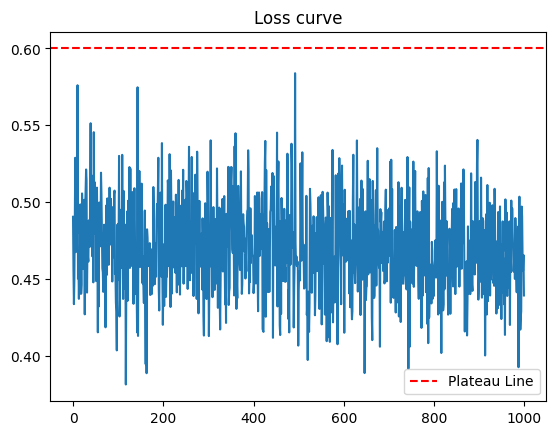

In [50]:
plt.plot(losses)
plt.title("Loss curve")
plt.axhline(y=0.6, color="r", linestyle="--", label="Plateau Line")
plt.legend()
plt.show()

With around 5-10k steps have seen a plateau at around 0.6 with the current architecture.

**Updates across the layers**

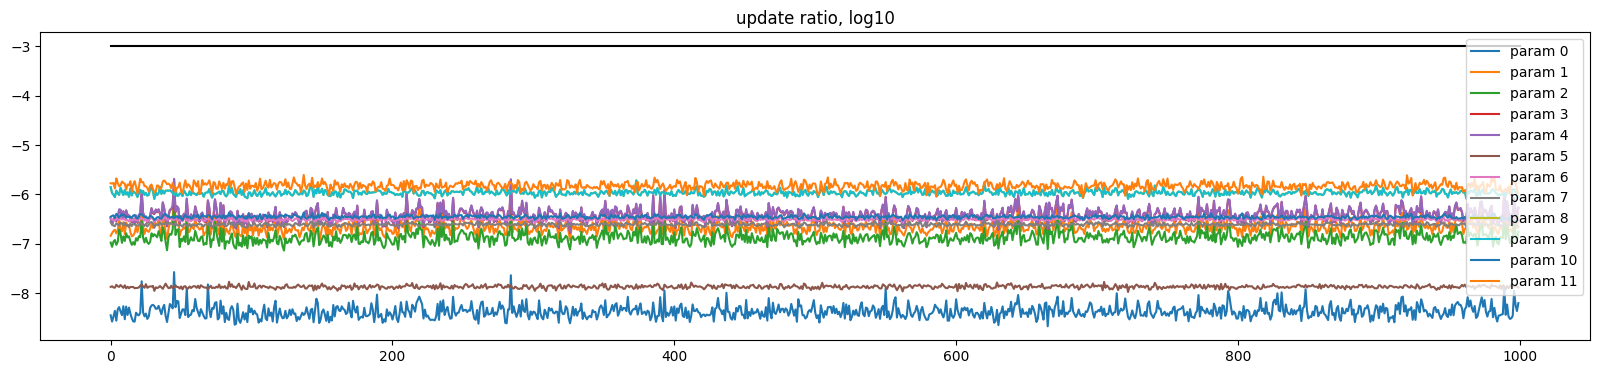

In [51]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(list(encoder.parameters()) + list(decoder.parameters())):

    plt.plot([updates[j][i] for j in range(len(updates))])
    legends.append('param %d' % i)
plt.plot([0, len(updates)], [-3, -3], 'k')
plt.title('update ratio, log10')
plt.legend(legends);

This plot clearly shows that the earlier layers are receiving negligible gradients. This is because each multiplication across the T dimension increases the variances of the hidden vectors. This results in vanishing gradients due to tanh saturation.

Additionally, aside from activations, architecturally, we pass through so many layers that the gradient inevitably becomes very small, even with perfect activations. Hence, we need to swap to LSTM/GRU implementations.

Ilya Sutskever et al. use an LSTM architecture to bridge the time gap between the input and output sequences.

To solve the issue, I will implement a similar LSTM architecture which uses gating mechanisms to preserve gradients over long sequences

## LSTM model

#### Description + Implemention

The architecture of the LSTM model is pretty much the same concept as in the vanilla RNN model. I manually implement the LSTM cells to highlight how the 4 key gates (input,forget,candidate and output gate) are used in this task. [This excellent article](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) discusses the LSTM in detail.

**Manual LSTM Cell**

I implement this manually for clearer understanding.


In [60]:
class LSTMCell(torch.nn.Module):
    """LSTM Cell class, taking in an input vector, the previous hidden state and passing through a LSTM cell to get the next hidden state."""
    def __init__(self, input_size, hidden_size, bias=True):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Input gate layer
        self.i2i = torch.nn.Linear(input_size, hidden_size)
        self.h2i = torch.nn.Linear(hidden_size, hidden_size)
        # Forget gate
        self.i2f = torch.nn.Linear(input_size, hidden_size)
        self.h2f = torch.nn.Linear(hidden_size, hidden_size)
        # Candidate gate
        self.i2g = torch.nn.Linear(input_size, hidden_size)
        self.h2g = torch.nn.Linear(hidden_size, hidden_size)
        # Output gate
        self.i2o = torch.nn.Linear(input_size, hidden_size)
        self.h2o = torch.nn.Linear(hidden_size, hidden_size)

        # Activations
        self.sigmoid = torch.nn.Sigmoid()
        self.tanh = torch.nn.Tanh()

    def forward(self, x, states):
        # We have B x Hidden_size vectors here plus the B x input_size input vectors
        h_prev, c_prev = states

        # Calculate input gate
        i = self.sigmoid(self.i2i(x) + self.h2i(h_prev))

        # Calculate forget gate
        f = self.sigmoid(self.i2f(x) + self.h2f(h_prev))

        # Calculate candidate gate
        g = self.tanh(self.i2g(x) + self.h2g(h_prev))

        # Calculate output gate
        o = self.sigmoid(self.i2o(x) + self.h2o(h_prev))

        # New cell state
        cx = f * c_prev + i * g
        # The new hidden state (actual output)
        hx = o * torch.tanh(cx)
        return hx, cx

**New Encoder/Decoder**

Exact same logic just instead of a vanilla RNN, we pass through LSTM cell.

In [87]:
class LSTMEncoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Embedding layer for the tokens
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.cell = torch.nn.LSTMCell(embedding_dim, hidden_dim)

    def forward(self, x):
        # Get 32 x 87 x character embeddings
        Xen = self.embedding(x)
        B, T, C = Xen.shape
        # Initialised the hidden and cell state vectors
        h, c = torch.zeros(B, self.hidden_dim), torch.zeros(B, self.hidden_dim)
        for t in range(T):
            inputx = Xen[:, t, :]
            h, c = self.cell(inputx, (h,c))

        return h, c

class LSTMDecoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.cell = torch.nn.LSTMCell(embedding_dim, hidden_dim)
        self.out = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, encoder_states):
        """
        Given the final encoder LSTM cell state and hidden state + input, produce/output logits for each T step in the sequence.
        """
        Xen = self.embedding(x)
        B, T, C = Xen.shape

        h,c = encoder_states

        outputs = []
        for t in range(T):
            inputx = Xen[:, t, :]
            h, c = self.cell(inputx,(h,c))
            logits_example = self.out(h)
            outputs.append(logits_example)

        logits = torch.stack(outputs, dim = 1)

        return logits, h, c

encoder = LSTMEncoder(VOCAB_SIZE_EN,EMBEDDING_DIM,HIDDEN_DIM)
decoder = LSTMDecoder(VOCAB_SIZE_FR,EMBEDDING_DIM,HIDDEN_DIM)

#### Training Loop

In [88]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder)}")
print(f"Decoder params: {count_parameters(decoder)}")
print(f"Total params:   {count_parameters(encoder) + count_parameters(decoder)}")

Encoder params: 1189376
Decoder params: 1247214
Total params:   2436590


In [94]:
lr=1e-5
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(
    params,
    lr=lr
)

In [95]:
MAX_STEPS = 2000
losses = []
updates = []



for step in range(MAX_STEPS):
    # Get batch tensors
    ix_b = torch.randint(0,Xtr_en.shape[0], size = (64,))
    Xbe,Xbf,Yb = Xtr_en[ix_b], Xtr_fr[ix_b], Ytr[ix_b]
    # Get hidden vectors from encoder
    states = encoder(Xbe)
    # Pass through decoder to get logits
    logitsb, _, _ = decoder(Xbf,states)
    # Permute for torch API
    logitsb= logitsb.permute(0,2,1)
    loss = F.cross_entropy(logitsb, Yb)

    # Optimisation
    optimizer.zero_grad()
    loss.backward()
    # Clip gradients
    torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
    optimizer.step()
    # Track stats
    losses.append(loss.item())
    with torch.no_grad():
        updates.append([((lr*p.grad).std()/p.data.std()).log10() for p in params])
    if step % 200 == 0:
        print(f"Step {step}: {loss.item()}")


Step 0: 0.38523930311203003
Step 200: 0.41828101873397827
Step 400: 0.4505142867565155
Step 600: 0.4023556113243103
Step 800: 0.4073503017425537
Step 1000: 0.4270513653755188
Step 1200: 0.4205256700515747
Step 1400: 0.4171013832092285
Step 1600: 0.4248977601528168
Step 1800: 0.3559924364089966


#### Inference

Try out this model if you are reading this, it has some really funny translations

In [110]:
# Change the range to generate more / less, change index of eng sentence for other starting point
for i in range(20):
    eng_sentence = Xte_en[1500 + i].view(1,-1)
    h,c = encoder(eng_sentence)

    curr_token = torch.tensor([[1]])

    decoded_indices = []

    max_generation_len = 50

    for i in range(max_generation_len):
        logits, h, c = decoder(curr_token, (h,c))
        probs = F.softmax(logits.squeeze() / 0.1, dim=0)

        next_token_idx = torch.argmax(probs).item()

        if next_token_idx == 0:
            break

        decoded_indices.append(next_token_idx)

        curr_token = torch.tensor([[next_token_idx]])

    print(decode_text(eng_sentence.tolist()[0],english = True))
    print(decode_text(decoded_indices), end = "\n\n")


Make it simple.<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
Arrête de faire ça.<EOS>.<EOS>.<EOS>.<EOS>.<EOS>.<EOS><EOS>»<EOS>

I'll be back in my office.<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>
Je suis désolé de ne pas vous aider.<EOS>.<EOS>.<EOS>.<EOS>.<EOS>.<EOS>.<EOS>.

Beat it.<EOS><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><P

#### Training Run 1

**Details**

* Around 30 mins training on M3 Pro chip
* 2.6 Million parameter model
* Training loss converged around 0.4
* Gradient clipping on optimisation (as per the paper)
* 4000 steps with 1e-3 lr, 4000 with 1e-4 and 2000 with 1e-5 (Just experimenting here)


**Samples**

> They are boiling water for tea. -> "Ils sont tous deux fois plus de temps.'
>
> He demands immediate payment. -> "Il a dit qu'il avait l'air de toi."
>
> I'll be there at six. -> "Je suis désolé de ne pas être prêt." (*funny one, it seems the model has a kind/remorseful personality by default :D*)

**Key Progress**

1) The model has a similar (perhaps improved) understanding of word formation and what French words look like as the vanilla RNN i.e. it can generate plausible sounding french words.
2) **Much better at encapsulating the meaning from the English sentence**, it can remember details all the way from the beginning of the sentence and does not struggle with the long-term dependencies like the vanilla RNN.
3) Not quite a full understanding of the meaning of the language/grammar. It has a really solid overall grasp of some concepts like tense and word order, but is lacking some understanding of higher level meaning.

**Thoughts**

I thought the results here were really cool for a first training run - I have not tweaked any network hyperparameters and I believe that with increased hidden vectors I could further improve the performance. Clearly, the LSTM architecture is vastly superior for learning over long-term dependencies (as expected). It seems that even if the translation is not 100% accurate, the encoder understands the meaning behind the english well enough to capture the main themes of the sentence and pass it to the decoder. A good example that demonstrates this is number 3 above - it understand the phrase I'll be there at six to be a temporal comment so it says "I am sorry, I'm not ready".

**Improvements**

Now it is clear to me that an architecture with Deep LSTMS should yield even greater performance, each layer will be able to learn different features of the sentence and encapsulate different aspects (grammar, word-order, meaning etc). Crucially, I hope that additional layers will provide the higher-level sentence structure that is missing from the current model.

I will not spend time tweaking this architecture as the ultimate goal was to recreate the paper. The final architecture I implement will be exactly the same Deep LSTM version as in the Seq2Seq paper, just scaled down parameter wise.


**My favourite translations from this model that I have found...**

You gave me hope. -> Tu es très bon. (You are very good.)

Just be careful. -> Laissez-moi vous aider. (Let me help you.)



*Pretty cute*



## Deep LSTM Model

#### Description + Implementation

* 2 Layer deep encoder and 2 layer deep decoder.
* First layer takes the raw character feature vectors as before, second layer works on the hidden state from layer 1 as input.
* The decoder layers are initialised with the corresponding cell state+ hidden state from the encoder. This can be seen as the first layer passing the info on grammar, for example, while the second passing info on high level sentence logic.

In [66]:
device = torch.device("mps")

class DeepLSTMEncoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.cells = torch.nn.ModuleList([
            torch.nn.LSTMCell(embedding_dim, hidden_dim),
            torch.nn.LSTMCell(hidden_dim, hidden_dim),
        ])

    def forward(self, x):
        Xen = self.embedding(x)
        B, T, C = Xen.shape

        states = []
        for _ in range(len(self.cells)):
            h, c = torch.zeros(B, self.hidden_dim), torch.zeros(B, self.hidden_dim)
            states.append((h,c))

        for t in range(T):
            inputx = Xen[:, t, :]

            for i in range(len(self.cells)):
                h_prev, c_prev = states[i]
                h, c = self.cells[i](inputx, (h_prev,c_prev))
                states[i] = (h,c)
                inputx = h

        return states

class DeepLSTMDecoder(torch.nn.Module):
    def __init__(self, vocab_size:int, embedding_dim:int, hidden_dim:int):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)
        self.cells = torch.nn.ModuleList([
            torch.nn.LSTMCell(embedding_dim, hidden_dim),
            torch.nn.LSTMCell(hidden_dim, hidden_dim),
        ])
        self.out = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, encoder_states):
        Xen = self.embedding(x)
        B, T, C = Xen.shape

        states = [s for s in encoder_states]
        outputs = []

        for t in range(T):
            inputx = Xen[:, t, :]

            for i in range(len(self.cells)):
                h_prev, c_prev = states[i]
                h, c = self.cells[i](inputx, (h_prev,c_prev))
                states[i] = (h,c)
                inputx = h

            logits_example = self.out(inputx)
            outputs.append(logits_example)

        return torch.stack(outputs, dim=1), states


encoder = DeepLSTMEncoder(VOCAB_SIZE_EN,EMBEDDING_DIM,HIDDEN_DIM)
decoder = DeepLSTMDecoder(VOCAB_SIZE_FR,EMBEDDING_DIM,HIDDEN_DIM)

#### Optimisation

In [67]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Encoder params: {count_parameters(encoder)}")
print(f"Decoder params: {count_parameters(decoder)}")
print(f"Total params:   {count_parameters(encoder) + count_parameters(decoder)}")

Encoder params: 3290624
Decoder params: 3348462
Total params:   6639086


In [68]:
lr=1e-3
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = torch.optim.Adam(
    params,
    lr=lr
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=500
)

In [69]:
MAX_STEPS = 20000
losses = []
updates = []

for step in range(MAX_STEPS):
    # Get batch tensors
    ix_b = torch.randint(0,Xtr_en.shape[0], size = (64,))
    Xbe,Xbf,Yb = Xtr_en[ix_b], Xtr_fr[ix_b], Ytr[ix_b]

    Xbe_reversed = torch.flip(Xbe, dims=[1])
    # Get hidden vectors from encoder
    states = encoder(Xbe_reversed)
    # Pass through decoder to get logits
    logitsb, _ = decoder(Xbf,states)
    # Permute for torch API
    logitsb= logitsb.permute(0,2,1)
    loss = F.cross_entropy(logitsb, Yb)

    # Optimisation
    optimizer.zero_grad()
    loss.backward()
    # Clip gradients
    torch.nn.utils.clip_grad_norm_(params, max_norm=5.0)
    optimizer.step()
    scheduler.step(loss.item())
    # Track stats
    current_lr = optimizer.param_groups[0]['lr']

    losses.append(loss.item())
    with torch.no_grad():
        updates.append([((current_lr*p.grad).std()/p.data.std()).log10() for p in params])
    if step % 200 == 0:
        print(f"Step {step}: {loss.item()}")


Step 0: 4.6851959228515625
Step 200: 0.9763606190681458
Step 400: 0.8000950813293457
Step 600: 0.6944912075996399
Step 800: 0.5823857188224792
Step 1000: 0.5245636105537415
Step 1200: 0.4882853031158447
Step 1400: 0.4881027638912201
Step 1600: 0.5011664032936096
Step 1800: 0.4621797800064087
Step 2000: 0.41977885365486145
Step 2200: 0.42799869179725647
Step 2400: 0.4318893551826477
Step 2600: 0.40666651725769043
Step 2800: 0.4077283442020416
Step 3000: 0.3819802701473236
Step 3200: 0.3689974546432495
Step 3400: 0.36207929253578186
Step 3600: 0.3582918047904968
Step 3800: 0.36233457922935486
Step 4000: 0.41356557607650757
Step 4200: 0.4149273931980133
Step 4400: 0.3924206793308258
Step 4600: 0.4134449064731598
Step 4800: 0.36551961302757263
Step 5000: 0.40343740582466125
Step 5200: 0.42131122946739197
Step 5400: 0.4370022416114807
Step 5600: 0.38306665420532227
Step 5800: 0.354242205619812
Step 6000: 0.381592333316803
Step 6200: 0.40349796414375305
Step 6400: 0.3972522020339966
Step 660

#### Inference

In [78]:
# Change the range to generate more / less, change index of eng sentence for other starting point
for i in range(50):
    eng_sentence = torch.flip(Xte_en[1500 + i],dims = [0])
    mask = (eng_sentence != 0)
    eng_sentence = eng_sentence[mask].view(1,-1)
    states = encoder(eng_sentence)

    curr_token = torch.tensor([[1]])

    decoded_indices = []

    max_generation_len = 50

    for i in range(max_generation_len):
        logits, states = decoder(curr_token, states)
        probs = F.softmax(logits.squeeze() / 0.1, dim=0)

        next_token_idx = torch.argmax(probs).item()

        if next_token_idx == 2:
            break

        decoded_indices.append(next_token_idx)

        curr_token = torch.tensor([[next_token_idx]])

    print(''.join(reversed(list(decode_text(eng_sentence.tolist()[0],english = True)))))
    print(decode_text(decoded_indices), end = "\n\n")


Make it simple.>SOE<
Rends-moi !

I'll be back in my office.>SOE<
Je serai de la maison de Mary.

Beat it.>SOE<
tendans le courant.

It would be better for you to stay in bed today.>SOE<
Il serait de tout ce que je veux dire un peu de te

A boy snatched my purse as he rode by on his bicycle.>SOE<
Un chien a été pris par la plus grande question de

You gave me hope.>SOE<
Tu m'as dit de faire ça.

Teachers also learn from their students.>SOE<
Les problèmes sont des problèmes de travail.

She left here long before you arrived.>SOE<
Elle a pris le plus grand que toi.

The baby is screaming.>SOE<
Le problème est très bon.

That's why I love you.>SOE<
C'est pourquoi je vous ai dit.

We have to solve this problem.>SOE<
Nous devons arrêter de faire ça.

You only live once.>SOE<
Vous vous aiderez une bonne idée.

He wore a light blue tie.>SOE<
Il a fait une petite chance.

Just be careful.>SOE<
Sous-moi pas si tu es en train de faire ça.

The sand on the beach is very hot.>SOE<
La police a été 

#### Training Run 1

**Details**

* Around 1 hour training on M3 Pro chip
* 6.6 Million parameter model
* Training loss converged around 0.4 again
* 4000 steps with 1e-3 lr, 4000 with 1e-4, 2000 with 1e-5


**Samples**

> Make it simple. -> "Les enfants sont en train de faire ça."
>
> It would be better for you to stay in bed today. -> "Il est très bon pour tout ce que je veux dire."
>
> A boy snatched my purse as he rode by on his bicycle. -> "Nous avons peur de l'argent de l'aide de l'aide.

**Key Notes**

1) Very minimal improvements compared to the 2.6million parameter model one with same iterations.
2) Training now taking ages




**Thoughts**

After training for 10k iterations, seeing the loss stop decreasing and samples not improving, I decided to just start over, throwing every trick I could at the optimisation for a final time. I didn't want to spend too long trying to make a perfect model as google translate already exists :).

#### The Grand Finale

**Details**

* Around 4 hours training on M3 Pro chip
* 6.6 Million parameter model
* Training loss converged around 0.35
* 20000 steps with torch ReduceLROnPlateau lr scheduler.

**Samples**

*Best samples*
>
> Don't speak. -> "Ne parlez pas."
>
> I was very tired. -> " J'étais très fatiguée. "
>
> He went home at six. -> "Il est allé à la maison."
>
> Tom bought a book. -> "Tom a acheté une chanson."
>
> I'm crazy. -> "Je suis intéressé."
>
> etc...


**Key Progress**

1) The model can accurately translate short sentences and the beginning of longer sentences
2) Good at understanding the overall theme of the sentences

**Thoughts**

In the end, the model has clearly mastered French grammar + structure - it accurately conjugates verbs, negates, and agrees tenses. It nearly always accurately translates the start of the english sentences. Reversing the word has clearly improved the ability of the translation to "connect the English with the French" as discussed in the paper. Overall, I am very happy with the results from such a small character level model (compared to the original paper).

Despite the successes, the model has a tendency to hallucinate specifics of words (e.g. nouns). The issue is likely a result of the compressed vectors (hidden + cell) not being able to retain such specific details, even though they understand the general theme of the sentence (this illustrates the Information Bottleneck inherent in encoder-decoder architectures). The decoder then receives a fuzzy/rough signal of the sentence which leads it to guess statistically likely nouns like "Tom" which is featured a lot.

**Improvements**

* Attention Mechanisms -> Will be explored in another folder but allow decoder to search the source sentence (with key and query vectors) to pick up on details, rather than relying on compressed memory.
* Larger hidden state/more parameters -> Requires more powerful hardware for me to train, I plan on returning to this project and training a larger parameter/deeper version at some point using cloud compute.


## Concluding Remark

In conclusion, we have successfully replicated the architecture from the Sequence to Sequence Learning with Neural Networks paper, demonstrating the clear evolution across three RNN architectures.

We began with a Vanilla RNN, which learned the surface-level syntax of French but failed to retain any semantic meaning from the English input. Moving to a Standard LSTM brought major improvements, as the gating mechanisms mitigated vanishing gradients and allowed the model to capture sentence themes. Finally, our 6.6m parameter Deep LSTM demonstrated the true power of the architecture: it mastered French grammar and perfectly translated short sequences.

While the input reversal trick significantly improved the alignment between source and target, we identified a persistent information bottleneck: without an attention mechanism, the model struggles to retain specific noun details in longer sequences, leading to semantic hallucinations. This project highlights both the revolutionary capability of Deep LSTMs and the necessity of the Attention mechanisms that followed.